# Stage 8 — Sentiment Analysis per Feature Category

Use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to assign sentiment
scores to each review, then aggregate by feature category to answer:

> *Which features are players praising? Which are they complaining about?*

**Output:** `data/processed/sentiment_by_feature.csv`

## 1. Imports & Data Load

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='darkgrid')

df = pd.read_csv('../data/processed/categorized_reviews.csv')
print(f'Loaded {len(df):,} categorized reviews')
print(f'Columns: {df.columns.tolist()}')

Loaded 282,547 categorized reviews
Columns: ['review', 'voted_up', 'votes_up', 'votes_funny', 'playtime_forever', 'created', 'clean_review', 'primary_category', 'has_category', 'cat_Performance', 'cat_Graphics', 'cat_Story', 'cat_Gameplay', 'cat_Combat', 'cat_Audio', 'cat_NPC_AI', 'cat_Open_World', 'cat_UI_UX', 'cat_Bugs']


## 2. VADER Sentiment Scoring

In [2]:
analyzer = SentimentIntensityAnalyzer()

# Test VADER on a sample
test_texts = [
    "The game crashes every 10 minutes, absolutely broken garbage!",
    "The story is absolutely incredible, best writing I've ever seen in a game.",
    "The graphics look okay but performance is terrible on my PC."
]
for t in test_texts:
    scores = analyzer.polarity_scores(t)
    print(f'Text: {t[:70]}...')
    print(f'Scores: {scores}\n')

Text: The game crashes every 10 minutes, absolutely broken garbage!...
Scores: {'neg': 0.315, 'neu': 0.685, 'pos': 0.0, 'compound': -0.5697}

Text: The story is absolutely incredible, best writing I've ever seen in a g...
Scores: {'neg': 0.0, 'neu': 0.716, 'pos': 0.284, 'compound': 0.6976}

Text: The graphics look okay but performance is terrible on my PC....
Scores: {'neg': 0.284, 'neu': 0.616, 'pos': 0.099, 'compound': -0.5719}



In [3]:
print('Running VADER on all reviews... (this may take a few minutes)')

# Truncate very long reviews for speed (VADER doesn't need full text)
def get_vader_scores(text):
    if not isinstance(text, str):
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
    # Use first 1000 chars for very long reviews
    return analyzer.polarity_scores(text[:1000])

vader_scores = df['review'].apply(get_vader_scores)

df['vader_neg'] = vader_scores.apply(lambda x: x['neg'])
df['vader_neu'] = vader_scores.apply(lambda x: x['neu'])
df['vader_pos'] = vader_scores.apply(lambda x: x['pos'])
df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])

# Classify sentiment label
def sentiment_label(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['vader_compound'].apply(sentiment_label)

print('VADER scoring complete!')
print(df['vader_sentiment'].value_counts())

Running VADER on all reviews... (this may take a few minutes)


VADER scoring complete!
vader_sentiment
positive    202653
neutral      40282
negative     39612
Name: count, dtype: int64


In [4]:
# VADER vs voted_up agreement
df_cat = df[df['has_category'] == True].copy()

print(f'Reviews with categories: {len(df_cat):,}')
agreement = (df_cat['voted_up'] == (df_cat['vader_compound'] > 0)).mean()
print(f'VADER vs voted_up agreement rate: {agreement:.2%}')

Reviews with categories: 172,767
VADER vs voted_up agreement rate: 81.04%


## 3. Aggregate Sentiment by Feature Category

In [5]:
# Identify category columns
cat_cols = [c for c in df.columns if c.startswith('cat_')]
categories = [c.replace('cat_', '') for c in cat_cols]

print(f'Aggregating sentiment across {len(categories)} categories...')

results = []
for cat, col in zip(categories, cat_cols):
    subset = df[df[col] == 1]
    if len(subset) == 0:
        continue
    
    total = len(subset)
    positive = (subset['vader_sentiment'] == 'positive').sum()
    negative = (subset['vader_sentiment'] == 'negative').sum()
    neutral = (subset['vader_sentiment'] == 'neutral').sum()
    avg_compound = subset['vader_compound'].mean()
    
    # Also check voted_up sentiment
    voted_positive = subset['voted_up'].sum() if 'voted_up' in subset.columns else 0
    voted_negative = total - voted_positive
    
    # Average helpful votes
    avg_helpful = subset['votes_up'].mean() if 'votes_up' in subset.columns else 0
    
    results.append({
        'category': cat,
        'total_mentions': total,
        'positive': int(positive),
        'negative': int(negative),
        'neutral': int(neutral),
        'avg_compound': round(avg_compound, 4),
        'pos_ratio': round(positive / total, 4),
        'neg_ratio': round(negative / total, 4),
        'voted_positive': int(voted_positive),
        'voted_negative': int(voted_negative),
        'avg_helpful_votes': round(avg_helpful, 2)
    })

sentiment_df = pd.DataFrame(results).sort_values('total_mentions', ascending=False)
print('\nSentiment by Feature Category:')
print(sentiment_df.to_string(index=False))

Aggregating sentiment across 10 categories...



Sentiment by Feature Category:
   category  total_mentions  positive  negative  neutral  avg_compound  pos_ratio  neg_ratio  voted_positive  voted_negative  avg_helpful_votes
       Bugs          109603     86546     17828     5229        0.5135     0.7896     0.1627           85662           23941               3.25
      Story           84305     70031     11923     2351        0.5873     0.8307     0.1414           69113           15192               3.86
   Gameplay           82195     69298     11734     1163        0.5828     0.8431     0.1428           66915           15280               3.89
   Graphics           64950     54238      9056     1656        0.5979     0.8351     0.1394           53245           11705               4.71
 Open_World           57518     45794     10086     1638        0.5417     0.7962     0.1754           45404           12114               5.11
     Combat           37797     28790      8391      616        0.4809     0.7617     0.2220           2

## 4. Visualize Sentiment by Feature

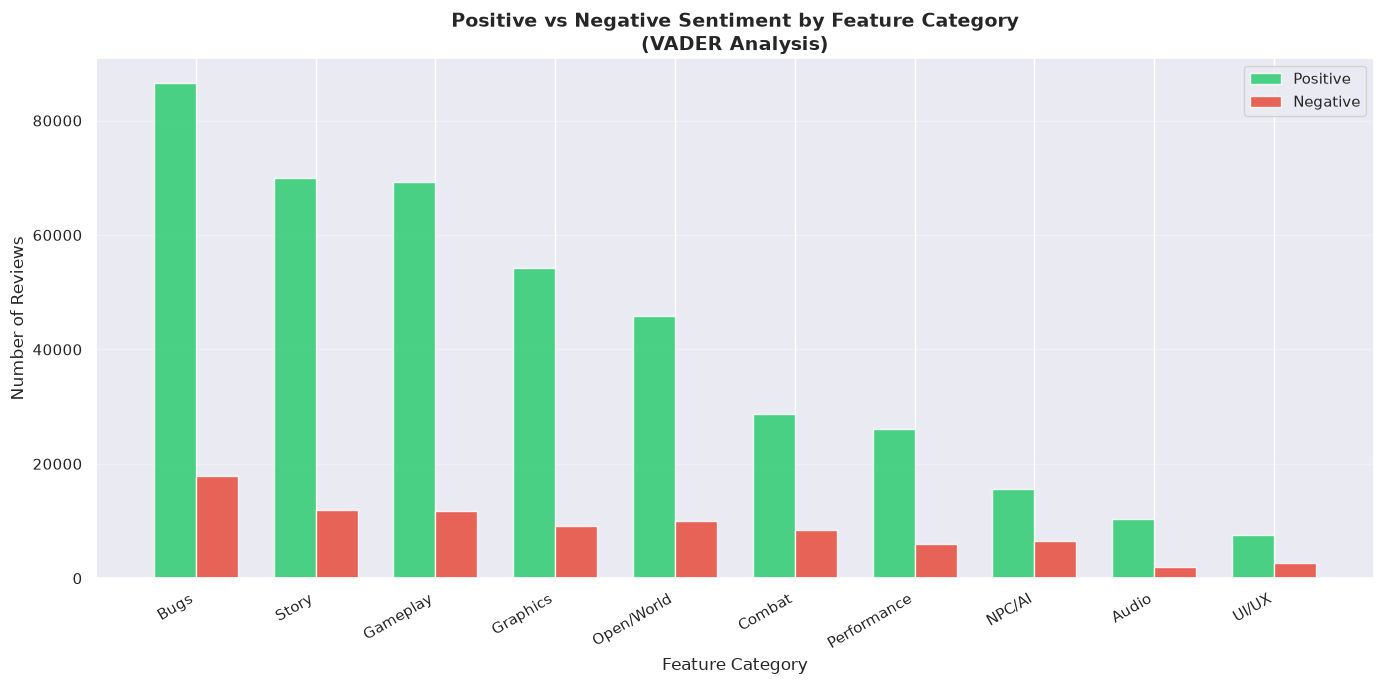

Saved chart.


In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(sentiment_df))
width = 0.35

bars1 = ax.bar(x - width/2, sentiment_df['positive'], width, label='Positive', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, sentiment_df['negative'], width, label='Negative', color='#e74c3c', alpha=0.85)

ax.set_xlabel('Feature Category', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Positive vs Negative Sentiment by Feature Category\n(VADER Analysis)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '/') for c in sentiment_df['category']], rotation=30, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/sentiment_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart.')

/tmp/ipykernel_151336/2420532576.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([c.replace('_', '/') for c in sentiment_df['category']], rotation=30, ha='right')


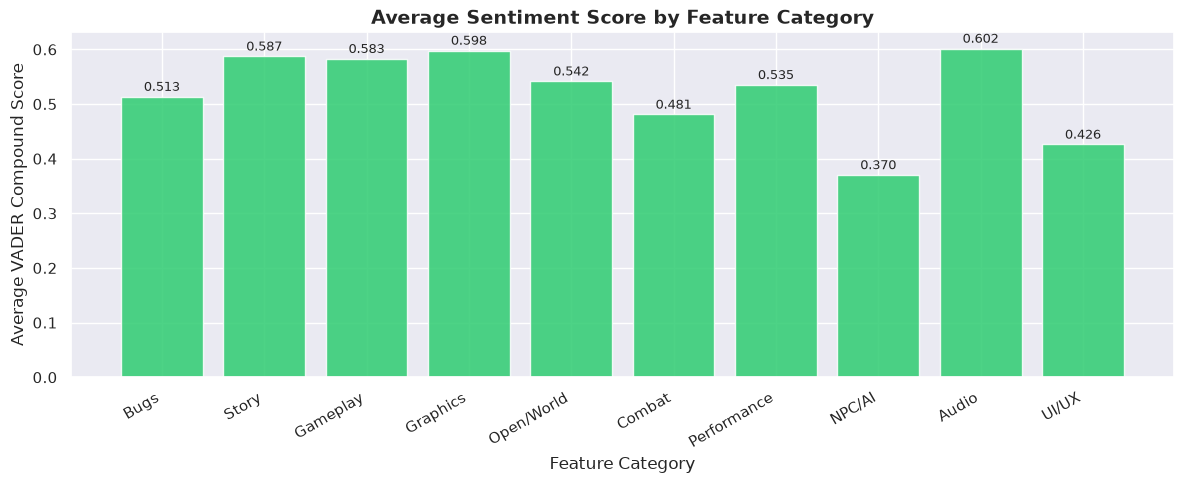

Saved chart.


In [7]:
# Average compound score chart
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sentiment_df['avg_compound']]
bars = ax.bar(sentiment_df['category'], sentiment_df['avg_compound'], color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Feature Category', fontsize=12)
ax.set_ylabel('Average VADER Compound Score', fontsize=12)
ax.set_title('Average Sentiment Score by Feature Category', fontsize=14, fontweight='bold')
ax.set_xticklabels([c.replace('_', '/') for c in sentiment_df['category']], rotation=30, ha='right')
ax.bar_label(bars, fmt='{:.3f}', padding=2, fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/avg_compound_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart.')

## 5. Save Results

In [8]:
# Save sentiment summary
sentiment_df.to_csv('../data/processed/sentiment_by_feature.csv', index=False)
print('Saved sentiment_by_feature.csv')

# Save full df with VADER scores
df.to_csv('../data/processed/reviews_with_sentiment.csv', index=False)
print(f'Saved reviews_with_sentiment.csv with {len(df):,} rows')

print('\nFinal sentiment summary:')
print(sentiment_df[['category', 'total_mentions', 'positive', 'negative', 'avg_compound']].to_string(index=False))

Saved sentiment_by_feature.csv


Saved reviews_with_sentiment.csv with 282,547 rows

Final sentiment summary:
   category  total_mentions  positive  negative  avg_compound
       Bugs          109603     86546     17828        0.5135
      Story           84305     70031     11923        0.5873
   Gameplay           82195     69298     11734        0.5828
   Graphics           64950     54238      9056        0.5979
 Open_World           57518     45794     10086        0.5417
     Combat           37797     28790      8391        0.4809
Performance           32874     26134      5969        0.5351
     NPC_AI           22481     15612      6441        0.3702
      Audio           12605     10413      1964        0.6016
      UI_UX           10406      7575      2635        0.4260
